In [22]:
# Design a 16 ns parametrized control pulse to implement a Hadamard gate in
# a transmon qubit while suppressing leakage to the |2> level.
#
# The pulse is parametrized as a Fourier series, so the optimizer works on a
# handful of coefficients (ux_basis/uy_basis) rather than the full
# per-timestep pulse.
# Estimated script runtime: ~2 seconds.

# AUTHOR:
#     Leo Van Damme / Technical University of Munich, 2025

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from grape_scq import Transmon, GateTarget, OptimizationProblem, GrapeOptimizer, initial_guess

In [24]:
# Physical system and target
n_steps = 160
n_coeffs = 3
# Analytic basis: ux(t) = sum ax(n)*fx(n,t), uy(t) = sum ay(n)*fy(n,t),
# using odd harmonics only -- fx/fy(n,t) = sin/cos((2n+1)*pi*t/T)
tau = np.linspace(0, 1, n_steps)
fx = np.array([np.sin((2*n+1)*np.pi*tau) for n in range(n_coeffs)])
fy = np.array([np.cos((2*n+1)*np.pi*tau) for n in range(n_coeffs)])

system = Transmon(n_levels=3, anharmonicity=-200e6)
target = GateTarget(matrix=np.array([[1, 1], [1, -1]])/np.sqrt(2), subspace=[0, 1])  # Hadamard
problem = OptimizationProblem(system, target, n_steps=n_steps, dt=0.1e-9,
                               ux_basis=fx, uy_basis=fy)

In [25]:
# Initial guess: random low-order Fourier coefficients
pulse0 = initial_guess.random_fourier(problem, n_coeffs=n_coeffs)

In [26]:
# Optimize the pulse
result = GrapeOptimizer(max_iter=500).optimize(problem, pulse0)

Compiling cost function... Done.


GRAPE optimization result
  cost:      0.999999 -> 0.000000
  fidelity:  0.000001 -> 1.000000
  iterations: 20
  message:   CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


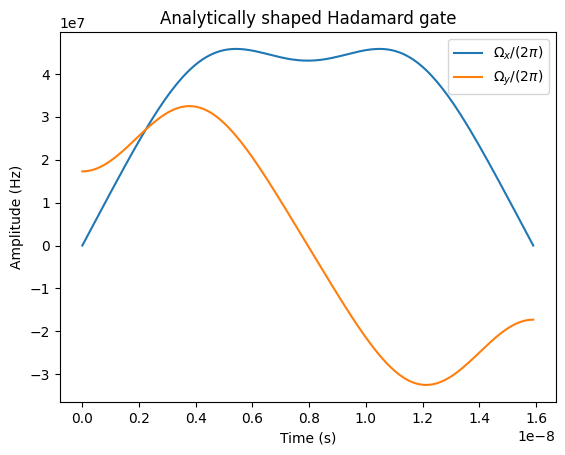

In [27]:
# Display in-phase and quadrature pulse components
result.plot_pulse(compare_to_initial=False)
plt.title("Analytically shaped Hadamard gate")
plt.show()

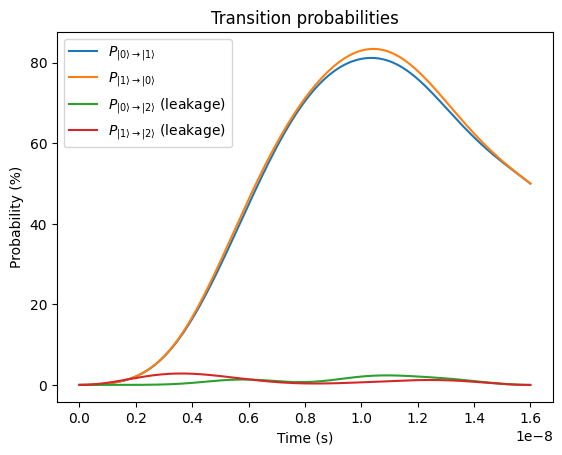

In [28]:
# Display transition probabilities
plt.figure()
plt.plot(problem.t, result.population(0, 1)*100, label=r'$P_{|0\rangle\rightarrow|1\rangle}$')
plt.plot(problem.t, result.population(1, 0)*100, label=r'$P_{|1\rangle\rightarrow|0\rangle}$')
plt.plot(problem.t, result.population(0, 2)*100, label=r'$P_{|0\rangle\rightarrow|2\rangle}$ (leakage)')
plt.plot(problem.t, result.population(1, 2)*100, label=r'$P_{|1\rangle\rightarrow|2\rangle}$ (leakage)')
plt.xlabel('Time (s)')
plt.ylabel('Probability (%)')
plt.legend()
plt.title("Transition probabilities")
plt.show()